## Import libraries

In [1]:
import os
import json
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
from numpy.typing import NDArray

%matplotlib inline

import matplotlib.pyplot as plt
from ipywidgets import interact_manual
from IPython.display import JSON, display

from datasets import load_dataset, load_from_disk

## Load the dataset

In [2]:
dataset_path = Path("dataset/quickdraw-small")

if dataset_path.exists():
    dataset = load_from_disk(str(dataset_path))
else:
    dataset = load_dataset("Xenova/quickdraw-small")
    dataset_path.parent.mkdir(parents=True, exist_ok=True)
    dataset.save_to_disk(str(dataset_path))
    

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4500000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 250000
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 250000
    })
})


## Visualizing the Dataset

In [3]:
train = dataset["train"]
examples = enumerate(train)

@interact_manual.options(manual_name="Next image")
def show_next():
    item = next(examples, None)
    
    if item is None:
        print("End of dataset.")
        return

    index, example = item
    label = train.features["label"].int2str(example["label"])

    fig = plt.figure(figsize=(3, 3))
    
    plt.imshow(example["image"].convert("RGB"))
    plt.title(f"Row {index} — {label}")
    plt.axis("off")
    plt.show()
    plt.close(fig)

interactive(children=(Button(description='Next image', style=ButtonStyle()), Output()), _dom_classes=('widget-…

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28 at 0x73A7ED743E00>, 'label': 116}


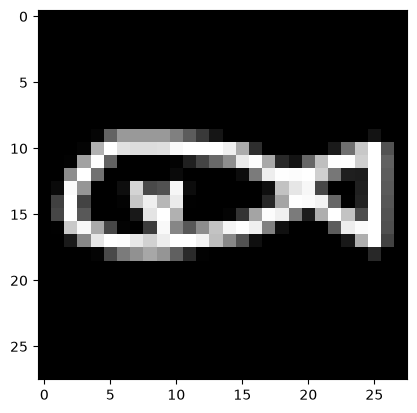

In [4]:
sample = train[22]
print(sample)
plt.imshow(sample["image"].convert("RGB"))
plt.show()

In [5]:
path = "dataset/quickdraw-small/train/dataset_info.json"

with open(path, encoding="utf-8") as file:
    info = json.load(file)

display(JSON(info))

<IPython.core.display.JSON object>

## Converting the data

In [6]:
train, test, valid = dataset["train"], dataset["test"], dataset["valid"]
print("Categories: " + str(len(info["features"]["label"]["names"])))

Categories: 345


In [7]:
def convert(
    data,
    split: str,
    batch_size: int = 32_768,
) -> tuple[NDArray[np.uint8], NDArray[np.int64]]:

    save_dir = Path("dataset/qd_numpy")
    save_dir.mkdir(parents=True, exist_ok=True)

    x_path = save_dir / f"x_{split}.npy"
    y_path = save_dir / f"y_{split}.npy"

    # Already converted -> load directly
    if x_path.exists() and y_path.exists():
        print(f"Loading cached {split} dataset...")

        x = np.load(x_path, mmap_mode="r")
        y = np.load(y_path, mmap_mode="r")

        return x, y

    print(f"Converting {split} dataset...")

    n = len(data)

    # Create the .npy files directly on disk
    x = np.lib.format.open_memmap(
        x_path,
        mode="w+",
        dtype=np.uint8,
        shape=(n, 1, 784),
    )

    y = np.lib.format.open_memmap(
        y_path,
        mode="w+",
        dtype=np.int64,
        shape=(n,),
    )

    data = data.with_format(
        "numpy",
        columns=["image", "label"],
    )

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        batch = data[start:end]

        x[start:end] = batch["image"].reshape(-1, 1, 784)
        y[start:end] = batch["label"]

    # everything is written to disk.
    x.flush()
    y.flush()

    print(f"Saved {split} dataset to {save_dir}")

    return x, y


# =============================================================
# Convert / Load datasets
# =============================================================

x_train, y_train = convert(train, "train")
x_test, y_test = convert(test, "test")
x_valid, y_valid = convert(valid, "valid")


# =============================================================
# Check results
# =============================================================

print("TRAIN")
print("x shape:", x_train.shape)
print("y shape:", y_train.shape)

print("single image shape:", x_train[0].shape)

print("x dtype:", x_train.dtype)
print("y dtype:", y_train.dtype)

print("pixel range:", x_train.min(), x_train.max())

print("first image:")
print(x_train[0])

print("first label:")
print(y_train[0])

print("-----------------------------------------------------------------------")

print("TEST")
print("x shape:", x_test.shape)
print("y shape:", y_test.shape)

print("-----------------------------------------------------------------------")

print("VALID")
print("x shape:", x_valid.shape)
print("y shape:", y_valid.shape)

Converting train dataset...
Saved train dataset to dataset/qd_numpy
Converting test dataset...
Saved test dataset to dataset/qd_numpy
Converting valid dataset...
Saved valid dataset to dataset/qd_numpy
TRAIN
x shape: (4500000, 1, 784)
y shape: (4500000,)
single image shape: (1, 784)
x dtype: uint8
y dtype: int64
pixel range: 0 255
first image:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 